# Classificação de Peças Metálicas com CNN

Neste notebook, será construída uma Rede Neural Convolucional para classificar peças metálicas como sem defeito ou defeituosas.

O desenvolvimento inclui ingestão das imagens, separação entre treino e validação, Data Augmentation, construção da CNN, treinamento e avaliação.

## 1. Configuração do ambiente

Nesta etapa, importamos as bibliotecas, definimos uma semente para tornar os resultados mais reproduzíveis e configuramos o caminho do dataset.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models

In [2]:
# Mantém maior consistência entre diferentes execuções.
SEMENTE = 42

np.random.seed(SEMENTE)
tf.random.set_seed(SEMENTE)

# Identifica a raiz do projeto.
RAIZ_PROJETO = Path.cwd()

if RAIZ_PROJETO.name == "notebooks":
    RAIZ_PROJETO = RAIZ_PROJETO.parent

PASTA_DATASET = RAIZ_PROJETO / "data" / "raw" / "casting_512x512"

print(f"Python: {sys.version.split()[0]}")
print(f"TensorFlow: {tf.__version__}")
print(f"Raiz do projeto: {RAIZ_PROJETO}")
print(f"Dataset encontrado: {PASTA_DATASET.exists()}")
print(f"Dispositivos disponíveis: {tf.config.list_physical_devices()}")

Python: 3.13.12
TensorFlow: 2.21.0
Raiz do projeto: c:\Users\USUARIO\Documents\Git-arquivos\sctec-inspecao-qualidade-cnn
Dataset encontrado: True
Dispositivos disponíveis: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


## 2. Ingestão e divisão do dataset

O TensorFlow carregará automaticamente as imagens a partir das pastas das classes. O conjunto será dividido em 80% para treinamento e 20% para validação.

As imagens serão redimensionadas para 128 × 128 pixels, reduzindo o custo computacional do treinamento sem alterar sua proporção quadrada.

In [3]:
ALTURA_IMAGEM = 128
LARGURA_IMAGEM = 128
TAMANHO_LOTE = 32
PERCENTUAL_VALIDACAO = 0.20

# A ordem define os rótulos: OK = 0 e Defeituosa = 1.
CLASSES_DIRETORIOS = ["ok_front", "def_front"]
NOMES_CLASSES = ["OK", "Defeituosa"]

In [4]:
dataset_treino = tf.keras.utils.image_dataset_from_directory(
    PASTA_DATASET,
    labels="inferred",
    label_mode="binary",
    class_names=CLASSES_DIRETORIOS,
    validation_split=PERCENTUAL_VALIDACAO,
    subset="training",
    seed=SEMENTE,
    image_size=(ALTURA_IMAGEM, LARGURA_IMAGEM),
    batch_size=TAMANHO_LOTE,
    shuffle=True,
)

Found 1300 files belonging to 2 classes.
Using 1040 files for training.


In [5]:
dataset_validacao = tf.keras.utils.image_dataset_from_directory(
    PASTA_DATASET,
    labels="inferred",
    label_mode="binary",
    class_names=CLASSES_DIRETORIOS,
    validation_split=PERCENTUAL_VALIDACAO,
    subset="validation",
    seed=SEMENTE,
    image_size=(ALTURA_IMAGEM, LARGURA_IMAGEM),
    batch_size=TAMANHO_LOTE,
    shuffle=True,
)

Found 1300 files belonging to 2 classes.
Using 260 files for validation.


In [6]:
print(f"Classes: {dataset_treino.class_names}")
print(f"Rótulo 0: {NOMES_CLASSES[0]}")
print(f"Rótulo 1: {NOMES_CLASSES[1]}")
print(f"Lotes de treino: {dataset_treino.cardinality().numpy()}")
print(f"Lotes de validação: {dataset_validacao.cardinality().numpy()}")

Classes: ['ok_front', 'def_front']
Rótulo 0: OK
Rótulo 1: Defeituosa
Lotes de treino: 33
Lotes de validação: 9


### 2.1 Verificação visual do carregamento

Antes do treinamento, exibimos algumas imagens de um lote para confirmar se o redimensionamento e os rótulos foram aplicados corretamente.

In [7]:
# Obtém um lote do conjunto de treinamento.
for imagens_lote, rotulos_lote in dataset_treino.take(1):
    print(f"Formato das imagens: {imagens_lote.shape}")
    print(f"Formato dos rótulos: {rotulos_lote.shape}")

Formato das imagens: (32, 128, 128, 3)
Formato dos rótulos: (32, 1)


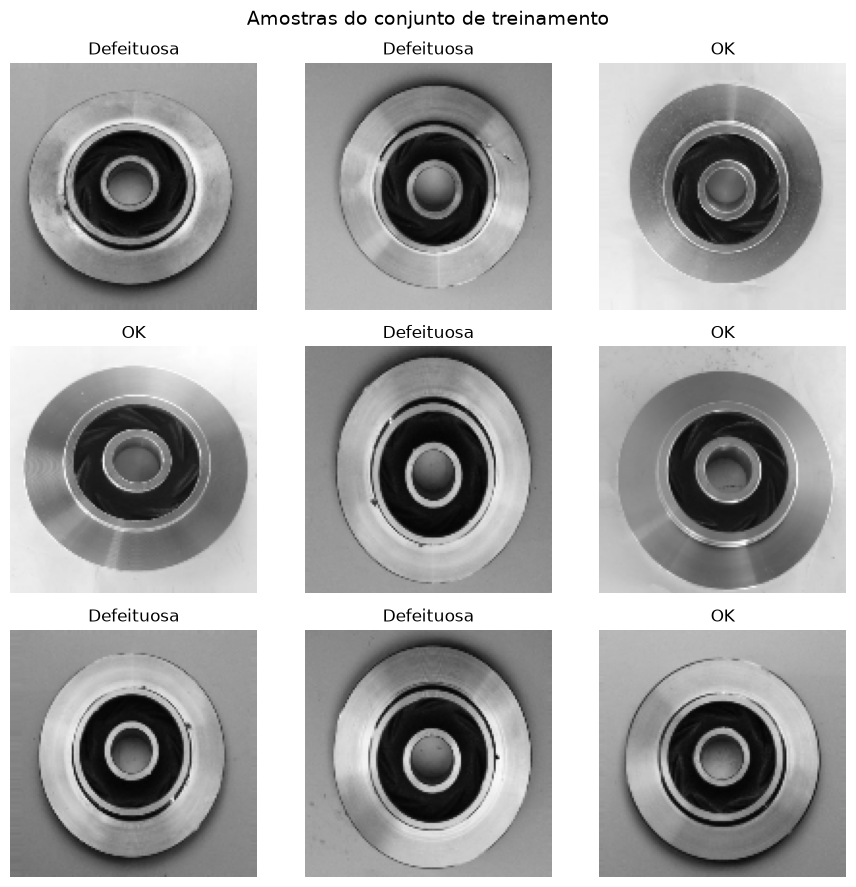

Figura salva em: c:\Users\USUARIO\Documents\Git-arquivos\sctec-inspecao-qualidade-cnn\outputs\figures\amostras_dataset_treino.png


In [8]:
figura, eixos = plt.subplots(3, 3, figsize=(9, 9))
eixos = eixos.flatten()

for indice, eixo in enumerate(eixos):
    # As imagens chegam como float32 entre 0 e 255.
    imagem = imagens_lote[indice].numpy().astype("uint8")
    rotulo = int(rotulos_lote[indice].numpy()[0])

    eixo.imshow(imagem)
    eixo.set_title(NOMES_CLASSES[rotulo])
    eixo.axis("off")

figura.suptitle(
    "Amostras do conjunto de treinamento",
    fontsize=14,
)

figura.tight_layout()

caminho_saida = (
    RAIZ_PROJETO
    / "outputs"
    / "figures"
    / "amostras_dataset_treino.png"
)

figura.savefig(caminho_saida, dpi=300, bbox_inches="tight")
plt.show()

print(f"Figura salva em: {caminho_saida}")

### Resultado da ingestão

As imagens e seus respectivos rótulos foram carregados corretamente. O redimensionamento para 128 × 128 pixels preservou o formato das peças e reduziu o custo computacional esperado durante o treinamento.

Também foram observadas variações de iluminação, contraste, escala e posicionamento. Essas diferenças serão consideradas na etapa de Data Augmentation.